In [11]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

In [12]:
procs_dyn = []
times_dyn = []

with open("timings_dynamic.txt") as f:
    next(f)
    for line in f:
        p, t = line.split()
        procs_dyn.append(int(p))
        times_dyn.append(float(t))

procs_dyn = np.array(procs_dyn)
times_dyn = np.array(times_dyn)

t1_dyn = times_dyn[0]
speedup_dyn = [t1_dyn/t for t in times_dyn]

In [13]:
procs_stat = []
times_stat = []

with open("../5_static/timings_static.txt") as f:
    next(f)
    for line in f:
        p, t = line.split()
        procs_stat.append(int(p))
        times_stat.append(float(t))

procs_stat = np.array(procs_stat)
times_stat = np.array(times_stat)

t1_stat = times_stat[0]
speedup_stat = [t1_stat/t for t in times_stat]

Estimated parallel fraction according to Amdahl's law:  [0.92665078]


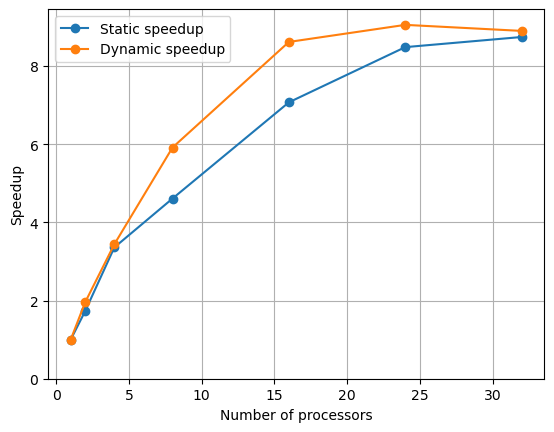

In [14]:
# Code from course 02610 Optimisation and data fitting
# Fit and plot speed up
n_proc = procs_dyn.flatten()
speedup_observation = np.array(speedup_dyn).flatten()
T1 = times_dyn[0]

def fun_f(F, n_proc, speedup_observation):
    p = n_proc
    return speedup_observation - T1 / ((1-F)*T1 + F/p *T1)

F0 = np.array([0.9])

# Solve using trust-region-reflective algorithm
from scipy.optimize import least_squares

plt.figure()
plt.plot(n_proc, speedup_stat, label='Static speedup', marker="o")

plt.plot(n_proc, speedup_observation, label='Dynamic speedup', marker="o")

# Solve using levenberg-marquardt algorithm
res = least_squares(fun_f, F0, args=(n_proc, speedup_observation), method='lm', ftol=1e-10, xtol=1e-10)
Fopt = res.x
print("Estimated parallel fraction according to Amdahl's law: ", Fopt)
#plt.plot(n_proc, T1 / ((1-Fopt)*T1 + Fopt/n_proc *T1), label='LM-fitted Amdahl')

plt.legend()
plt.xlabel("Number of processors")
plt.ylabel("Speedup")
#plt.xlim(np.min(n_proc),np.max(n_proc))
plt.ylim(0)
#plt.savefig('5_static_fitted_speedup.png')
plt.grid(True)

plt.show()


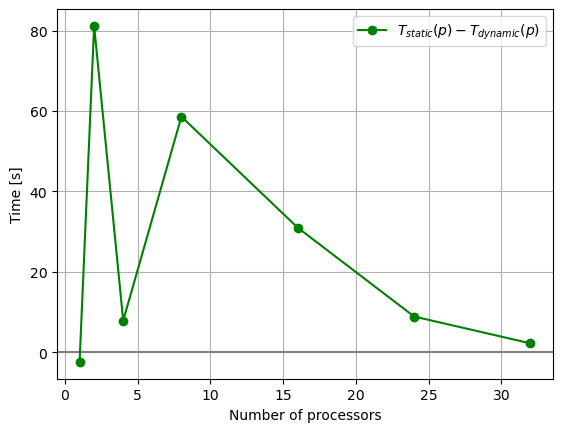

In [22]:
plt.figure()
plt.axhline(y=0, color='grey', linestyle='-')

time_diff = times_stat-times_dyn
plt.plot(n_proc, time_diff, marker="o", color="g", label='$T_{static}(p)-T_{dynamic}(p)$')

plt.legend()
plt.xlabel("Number of processors")
plt.ylabel("Time [s]")
#plt.xlim(np.min(n_proc),np.max(n_proc))
plt.grid(True)
plt.show()


In [16]:
time_diff.max(), time_diff.min(), time_diff.mean()

(np.float64(81.17809999999997),
 np.float64(-2.4148999999999887),
 np.float64(26.756685714285705))

In [17]:
time_diff.argmax(), time_diff.argmin()

(np.int64(1), np.int64(0))

In [10]:
# Theoretical max speedup
S_max = 1/(1-Fopt)
our_S_max = np.max(speedup_observation)
our_S_max_index = np.argmax(speedup_observation)
our_S_max_cores = procs_dyn[our_S_max_index]

# Time to compute for all buildings
n_buildings = 4571
n_observations = 100
observations_per_chunk = n_observations/our_S_max_cores
all_buildings_per_chunk = n_buildings/our_S_max_cores
times_longer_for_all = all_buildings_per_chunk/observations_per_chunk

# Print results for project handin
print(f"Theoretical max speedup: {S_max}.")
print(f"Acheived of theoretical max speedup: {our_S_max/S_max} using {our_S_max_cores} cores.")
print(f"Theoretically, it would take {times_longer_for_all} times longer computing all buildings.")
print(f"With {n_observations} buildings it took {times_dyn[our_S_max_index]} seconds, meaning {times_dyn[our_S_max_index]/60/60} hours.")
print(f"With {n_buildings} buildings it will estimatetly take {times_dyn[our_S_max_index]*times_longer_for_all} seconds, meaning {times_dyn[our_S_max_index]*times_longer_for_all/60/60} hours.")

Theoretical max speedup: [13.63341048].
Acheived of theoretical max speedup: [0.66423593] using 24 cores.
Theoretically, it would take 45.71 times longer computing all buildings.
With 100 buildings it took 136.44 seconds, meaning 0.0379 hours.
With 4571 buildings it will estimatetly take 6236.6724 seconds, meaning 1.732409 hours.


In [24]:
(6236.6724-6445.65852)/60

-3.483101999999993